# Notebook 1: Data Loading & Exploration

**Site Revenue Prediction ML System - SageMaker Notebook Series**

This notebook covers:
- Loading raw CSV data files
- Understanding the data structure and relationships
- Joining multiple data sources
- Feature aggregation and transformation
- Exploratory data analysis (EDA)
- Data quality checks

## Data Sources

| File | Description | Records |
|------|-------------|---------|
| `site_scores_revenue_and_diagnostics.csv` | Monthly revenue & auction data per site | ~500K rows |
| `Sites - Base Data Set.csv` | Site metadata, capabilities, restrictions | ~68K sites |
| `Site Revenue - Salesforce.csv` | Salesforce revenue summary | ~68K sites |
| `nearest_site_distances.csv` | Distance to nearest GSTV site | ~68K sites |
| `site_interstate_distances.csv` | Distance to nearest interstate | ~68K sites |
| `site_kroger_distances.csv` | Distance to nearest Kroger | ~27K sites |
| `site_mcdonalds_distances.csv` | Distance to nearest McDonald's | ~27K sites |

## SageMaker Notes
- Data should be stored in S3 and accessed via `s3://bucket/path`
- For local development, use the local CSV files
- Recommended instance: `ml.t3.medium` for exploration, `ml.m5.xlarge` for large datasets

In [74]:
# SageMaker-compatible imports
import sys
import os

# Add parent directory to path for local imports (SageMaker will use installed packages)
sys.path.insert(0, os.path.dirname(os.path.abspath('')))

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

print(f"Polars version: {pl.__version__}")
print(f"NumPy version: {np.__version__}")

Polars version: 1.37.1
NumPy version: 2.4.1


## 1. Configure Data Paths

For SageMaker, data is typically stored in S3. Update the paths below based on your environment.

**Key Data Files:**
- `site_scores_revenue_and_diagnostics.csv` - The main monthly data (~971MB, ~500K records)
- Distance files for geospatial features
- Base data set with site metadata

In [75]:
# Configuration - Update these paths for your environment
from pathlib import Path

# Local development paths
DATA_DIR = Path('../data/input')

# Main data files
SITE_SCORES_FILE = DATA_DIR / 'site_scores_revenue_and_diagnostics.csv'
BASE_DATA_FILE = DATA_DIR / 'Sites - Base Data Set.csv'
REVENUE_FILE = DATA_DIR / 'Site Revenue - Salesforce.csv'

# Geospatial distance files
NEAREST_SITE_FILE = DATA_DIR / 'nearest_site_distances.csv'
INTERSTATE_FILE = DATA_DIR / 'site_interstate_distances.csv'
KROGER_FILE = DATA_DIR / 'site_kroger_distances.csv'
MCDONALDS_FILE = DATA_DIR / 'site_mcdonalds_distances.csv'

# SageMaker S3 paths (uncomment and update for SageMaker)
# import sagemaker
# session = sagemaker.Session()
# bucket = session.default_bucket()
# DATA_DIR = f's3://{bucket}/site-scoring/data/input'

print("Data directory:", DATA_DIR)
print("\nFiles to load:")
for f in [SITE_SCORES_FILE, BASE_DATA_FILE, REVENUE_FILE, NEAREST_SITE_FILE, 
          INTERSTATE_FILE, KROGER_FILE, MCDONALDS_FILE]:
    exists = "✓" if f.exists() else "✗"
    size = f"{f.stat().st_size / 1024 / 1024:.1f} MB" if f.exists() else "NOT FOUND"
    print(f"  {exists} {f.name}: {size}")

Data directory: ../data/input

Files to load:
  ✓ site_scores_revenue_and_diagnostics.csv: 926.7 MB
  ✓ Sites - Base Data Set.csv: 16.9 MB
  ✓ Site Revenue - Salesforce.csv: 5.1 MB
  ✓ nearest_site_distances.csv: 6.5 MB
  ✓ site_interstate_distances.csv: 3.8 MB
  ✓ site_kroger_distances.csv: 2.7 MB
  ✓ site_mcdonalds_distances.csv: 2.8 MB


## 2. Load Main Site Scores Data

The main data file contains **monthly records** for each site. Each row represents one site's performance for one month.

This is the largest file (~971MB) and contains:
- Revenue and auction metrics (impressions, NVIs, revenue)
- Site metadata (network, program, hardware type)
- Demographics (income, age, gender percentages)
- Capability and restriction flags

In [76]:
# Load main site scores data using Polars (fast CSV reading)
print("Loading site_scores_revenue_and_diagnostics.csv...")
print("(This may take 30-60 seconds for the ~971MB file)")

df_scores = pl.read_csv(
    SITE_SCORES_FILE,
    infer_schema_length=10000,
    null_values=["", "NA", "null", "Unknown"]
)

print(f"\n✓ Loaded {len(df_scores):,} monthly records")
print(f"  Unique sites: {df_scores['id_gbase'].n_unique():,}")
print(f"  Date range: {df_scores['date'].min()} to {df_scores['date'].max()}")
print(f"  Memory usage: {df_scores.estimated_size('mb'):.1f} MB")
print(f"  Columns: {len(df_scores.columns)}")

Loading site_scores_revenue_and_diagnostics.csv...
(This may take 30-60 seconds for the ~971MB file)

✓ Loaded 1,475,761 monthly records
  Unique sites: 57,675
  Date range: 2022-01-01 to 2025-11-01
  Memory usage: 634.3 MB
  Columns: 94


In [77]:
# Preview the raw monthly data structure
print("Sample of monthly site data:")
df_scores.head(3)

Sample of monthly site data:


date,id_gbase,month,year,monthly_impressions,monthly_nvis,avg_daily_impressions,avg_daily_nvis,avg_latency,screen_count,revenue,site_activated_date,network,state,gtvid,county,latitude,longitude,zip,zip_4,dma,dma_rank,statuis,program,experience_type,hardware_type,retailer,avg_household_income,median_age,index_african_american,pct_african_american,index_asian,pct_asian,index_female,pct_female,index_male,pct_male,…,r_cpg_beverage_wine_video,r_finance_credit_cards,r_cpg_cbd_hemp_ingestibles_non_thc,r_cpg_non_food_beverage_cannabis_medical,r_cpg_non_food_beverage_cannabis_recreational,r_cpg_non_food_beverage_cbd_hemp_non_thc,r_alcohol_drink_responsibly_message,r_alternative_transportation,r_associations_and_npo_anti_smoking,r_automotive_after_market_oil,r_cpg_beverage_spirits_ooh,r_cpg_beverage_spirits_video,r_cpg_non_food_beverage_e_cigarette,r_entertainment_casinos_and_gambling,r_government_political,r_automotive_electric,r_recruitment,r_restaurants_cdr,r_restaurants_qsr,r_retail_automotive_service,r_retail_grocery,r_retail_grocerty_with_fuel,c_emv_enabled,c_nfc_enabled,c_open_24_hours,c_sells_beer,c_sells_diesel_fuel,c_sells_lottery,c_vistar_programmatic_enabled,c_walk_up_enabled,c_sells_wine,brand_fuel,brand_restaurant,brand_c_store,monthly_impressions_per_screen,monthly_nvis_per_screen,monthly_revenue_per_screen
str,str,i64,i64,i64,i64,i64,i64,str,i64,f64,str,str,str,str,str,f64,f64,i64,str,str,i64,str,str,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,str,str,str,str,str,bool,str,str,str,str,str,f64,f64,f64
"""2023-06-01""","""59ec02473055c91000eb2f10""",6,2023,null,null,null,null,null,8,0.0,"""2016-11-12""","""Gilbarco""","""FL""","""TAG017""","""Hamilton County""",30.519837,-83.056566,32052,"""32052-4309""","""Tallahassee-Thomasville FL-GA""",105,"""Active""","""Standard ICS""","""Standard GSTV""","""Flex Pay IV - 10.4 Inch""","""Johnson & Johnson, Inc.""",47534,36.2,315.02,39.73,5.74,0.32,69.845494,35.519896,131.203678,64.480104,…,false,false,false,true,true,false,false,false,false,false,false,false,false,false,false,false,false,true,true,false,false,false,null,"""Yes""","""No""","""Yes""",null,"""Yes""",true,null,"""No""","""Marathon""","""Burger King""","""Busy Bee""",null,null,0.0
"""2023-06-01""","""59ec025b0ce7611100819bb8""",6,2023,2324,2324,77,77,null,8,160.24,"""2016-11-15""","""Gilbarco""","""MD""","""BLG086""","""Baltimore City""",39.346382,-76.609371,21212,"""21212-4730""","""Baltimore MD""",29,"""Active""","""Applause - Verifone Owned""","""Standard GSTV""","""Flex Pay IV - 10.4 Inch""","""Sunoco Inc.""",131819,38.6,310.62,39.17,82.92,4.63,105.868717,53.83949,93.927092,46.16051,…,false,true,true,false,true,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,null,"""Yes""","""No""","""No""",null,"""Yes""",true,null,"""No""","""Sunoco""",null,"""Sunoco""",290.5,290.5,20.03
"""2023-06-01""","""59ec02b80ce7611100819e20""",6,2023,1115,1114,101,101,null,8,9.42,"""2021-08-25""","""Dover""","""VA""","""RLE070""","""Montgomery County""",37.128045,-80.417762,24073,"""24073-3355""","""Roanoke-Lynchburg VA""",70,"""Temporarily Deactivated""","""Dover - IOTV2""","""Standard GSTV""","""Wayne Integrated 10""","""Bandys Inc""",79435,36.8,39.61,4.99,41.69,2.33,101.265791,51.498674,98.690168,48.501326,…,false,true,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,null,"""Yes""","""No""","""Yes""",null,"""Yes""",true,null,"""Yes""","""Sunoco""",null,"""Lucky Stop""",139.375,139.25,1.1775


In [78]:
# Show key columns and types
key_columns = [
    'id_gbase', 'gtvid', 'date', 'network', 'statuis',  # Note: 'statuis' is a typo in source data
    'revenue', 'monthly_impressions', 'monthly_nvis',
    'avg_household_income', 'median_age'
]

print("Key columns in site scores data:")
print("=" * 60)
for col in key_columns:
    if col in df_scores.columns:
        dtype = df_scores[col].dtype
        null_count = df_scores[col].null_count()
        sample = df_scores[col].drop_nulls().head(1).to_list()
        sample_str = str(sample[0]) if sample else "N/A"
        print(f"{col:25} | {str(dtype):15} | nulls: {null_count:6,} | e.g. {sample_str[:30]}")

Key columns in site scores data:
id_gbase                  | String          | nulls:      0 | e.g. 59ec02473055c91000eb2f10
gtvid                     | String          | nulls:      0 | e.g. TAG017
date                      | String          | nulls:      0 | e.g. 2023-06-01
network                   | String          | nulls:      0 | e.g. Gilbarco
statuis                   | String          | nulls:      0 | e.g. Active
revenue                   | Float64         | nulls:      0 | e.g. 0.0
monthly_impressions       | Int64           | nulls: 135,164 | e.g. 2324
monthly_nvis              | Int64           | nulls: 153,888 | e.g. 2324
avg_household_income      | Int64           | nulls:  2,269 | e.g. 47534
median_age                | Float64         | nulls:  2,017 | e.g. 36.2


## 3. Load Auxiliary Data Files

The geospatial distance files provide additional features that help the model understand site location context:
- **Nearest site distance**: Competition/cannibalization indicator
- **Interstate distance**: Traffic accessibility proxy
- **Kroger/McDonald's distance**: Retail density indicators

In [79]:
# Load auxiliary geospatial data files
print("Loading auxiliary data files...")

# Nearest site distances
df_nearest = pl.read_csv(NEAREST_SITE_FILE)
print(f"✓ Nearest sites: {len(df_nearest):,} records")

# Interstate distances (some sites have multiple - we'll take minimum)
df_interstate = pl.read_csv(INTERSTATE_FILE)
print(f"✓ Interstate distances: {len(df_interstate):,} records")

# Kroger distances
df_kroger = pl.read_csv(KROGER_FILE)
print(f"✓ Kroger distances: {len(df_kroger):,} records")

# McDonald's distances
df_mcdonalds = pl.read_csv(MCDONALDS_FILE)
print(f"✓ McDonald's distances: {len(df_mcdonalds):,} records")

# Base data set (site metadata)
df_base = pl.read_csv(BASE_DATA_FILE)
print(f"✓ Base data set: {len(df_base):,} records")

# Salesforce revenue
df_revenue = pl.read_csv(REVENUE_FILE)
print(f"✓ Salesforce revenue: {len(df_revenue):,} records")

Loading auxiliary data files...
✓ Nearest sites: 67,644 records
✓ Interstate distances: 70,300 records
✓ Kroger distances: 57,675 records
✓ McDonald's distances: 57,675 records
✓ Base data set: 67,650 records
✓ Salesforce revenue: 67,604 records


## 4. Understand Data Relationships

The data files join on different ID columns:
- `id_gbase`: MongoDB-style ID (used in main site scores data)
- `GTVID`: Site identifier (used in distance files)
- The main scores file contains both, allowing us to join everything together

In [80]:
# Examine ID formats and overlap
print("ID Format Analysis:")
print("=" * 60)

# Main scores file IDs
scores_gbase = set(df_scores['id_gbase'].unique().to_list())
scores_gtvid = set(df_scores['gtvid'].unique().to_list())
print(f"Site scores - id_gbase: {len(scores_gbase):,} unique")
print(f"Site scores - gtvid: {len(scores_gtvid):,} unique")
print(f"  Sample id_gbase: {list(scores_gbase)[:2]}")
print(f"  Sample gtvid: {list(scores_gtvid)[:2]}")

# Distance file IDs (use GTVID)
nearest_ids = set(df_nearest['GTVID'].unique().to_list())
interstate_ids = set(df_interstate['GTVID'].unique().to_list())
kroger_ids = set(df_kroger['GTVID'].unique().to_list())

print(f"\nNearest site file - GTVID: {len(nearest_ids):,} unique")
print(f"Interstate file - GTVID: {len(interstate_ids):,} unique")
print(f"Kroger file - GTVID: {len(kroger_ids):,} unique")

# Check overlap
overlap_nearest = len(scores_gtvid & nearest_ids)
overlap_interstate = len(scores_gtvid & interstate_ids)
overlap_kroger = len(scores_gtvid & kroger_ids)

print(f"\nJoin overlap with site scores:")
print(f"  Nearest sites: {overlap_nearest:,} ({overlap_nearest/len(scores_gtvid)*100:.1f}%)")
print(f"  Interstate: {overlap_interstate:,} ({overlap_interstate/len(scores_gtvid)*100:.1f}%)")
print(f"  Kroger: {overlap_kroger:,} ({overlap_kroger/len(scores_gtvid)*100:.1f}%)")

ID Format Analysis:
Site scores - id_gbase: 57,675 unique
Site scores - gtvid: 57,675 unique
  Sample id_gbase: ['5a737fe6c2b1771200fcec56', '5e6ba1ab7a26736c65b3c4f0']
  Sample gtvid: ['KNE054', 'ORG203']

Nearest site file - GTVID: 67,644 unique
Interstate file - GTVID: 67,644 unique
Kroger file - GTVID: 57,675 unique

Join overlap with site scores:
  Nearest sites: 57,651 (100.0%)
  Interstate: 57,651 (100.0%)
  Kroger: 57,675 (100.0%)


In [81]:
# Preview distance data structure
print("Nearest Site Distances:")
print(df_nearest.head(3))

print("\nInterstate Distances:")
print(df_interstate.head(3))

print("\nKroger Distances:")
print(df_kroger.head(3))

Nearest Site Distances:
shape: (3, 8)
┌────────┬───────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┐
│ GTVID  ┆ Latitude  ┆ Longitude  ┆ nearest_si ┆ nearest_si ┆ nearest_si ┆ nearest_si ┆ nearest_si │
│ ---    ┆ ---       ┆ ---        ┆ te         ┆ te_lat     ┆ te_lon     ┆ te_distanc ┆ te_distanc │
│ str    ┆ f64       ┆ f64        ┆ ---        ┆ ---        ┆ ---        ┆ e_m        ┆ e_mi       │
│        ┆           ┆            ┆ str        ┆ f64        ┆ f64        ┆ ---        ┆ ---        │
│        ┆           ┆            ┆            ┆            ┆            ┆ f64        ┆ f64        │
╞════════╪═══════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ SFR001 ┆ 37.269033 ┆ -121.95607 ┆ SFG297     ┆ 37.269625  ┆ -121.95622 ┆ 67.682239  ┆ 0.042056   │
│        ┆           ┆ 2          ┆            ┆            ┆ 3          ┆            ┆            │
│ GHR001 ┆ 36.088931 ┆ -79.927743 ┆ GHG026     ┆ 36.0

## 5. Aggregate Monthly Data to Site Level

The ML model needs **one row per site**. We aggregate the monthly data to compute:
- **Total metrics**: Sum across all months (total_revenue, total_impressions, etc.)
- **Average metrics**: Mean per active month (avg_monthly_revenue, etc.)
- **Active months**: Count of months the site has data (tenure indicator)

In [82]:
# Aggregate monthly records to one row per site
print("Aggregating monthly data to site level...")

# Sort by date to get most recent values
df_sorted = df_scores.sort(['id_gbase', 'date'])

# Define aggregation
site_agg = df_sorted.group_by('id_gbase').agg([
    # Count of active months
    pl.len().alias('active_months'),
    
    # Date range
    pl.col('date').min().alias('first_month'),
    pl.col('date').max().alias('last_month'),
    
    # Most recent metadata (last value)
    pl.col('gtvid').last().alias('gtvid'),
    pl.col('network').last().alias('network'),
    pl.col('statuis').last().alias('status'),  # Note: 'statuis' is source typo
    pl.col('program').last().alias('program'),
    pl.col('experience_type').last().alias('experience_type'),
    pl.col('hardware_type').last().alias('hardware_type'),
    pl.col('retailer').last().alias('retailer'),
    pl.col('latitude').last().alias('latitude'),
    pl.col('longitude').last().alias('longitude'),
    pl.col('dma_rank').last().alias('dma_rank'),
    
    # Demographics (last available)
    pl.col('avg_household_income').last().alias('avg_household_income'),
    pl.col('median_age').last().alias('median_age'),
    pl.col('pct_female').last().alias('pct_female'),
    pl.col('pct_male').last().alias('pct_male'),
    
    # Brands
    pl.col('brand_fuel').last().alias('brand_fuel'),
    pl.col('brand_restaurant').last().alias('brand_restaurant'),
    pl.col('brand_c_store').last().alias('brand_c_store'),
    
    # Revenue metrics - totals
    pl.col('revenue').sum().alias('total_revenue'),
    pl.col('monthly_impressions').sum().alias('total_monthly_impressions'),
    pl.col('monthly_nvis').sum().alias('total_monthly_nvis'),
    pl.col('monthly_impressions_per_screen').sum().alias('total_monthly_impressions_per_screen'),
    pl.col('monthly_nvis_per_screen').sum().alias('total_monthly_nvis_per_screen'),
    pl.col('monthly_revenue_per_screen').sum().alias('total_monthly_revenue_per_screen'),
])

# Calculate averages per active month
for col in ['revenue', 'monthly_impressions', 'monthly_nvis', 
            'monthly_impressions_per_screen', 'monthly_nvis_per_screen', 
            'monthly_revenue_per_screen']:
    total_col = f'total_{col}'
    if total_col in site_agg.columns:
        site_agg = site_agg.with_columns(
            (pl.col(total_col) / pl.col('active_months')).alias(f'avg_monthly_{col}')
        )

print(f"✓ Aggregated to {len(site_agg):,} unique sites")
print(f"  Columns: {len(site_agg.columns)}")

Aggregating monthly data to site level...
✓ Aggregated to 57,675 unique sites
  Columns: 33


In [83]:
# Preview aggregated site data
print("Sample of aggregated site data:")
site_agg.select(['id_gbase', 'gtvid', 'active_months', 'status', 
                 'total_revenue', 'avg_monthly_revenue']).head(5)

Sample of aggregated site data:


id_gbase,gtvid,active_months,status,total_revenue,avg_monthly_revenue
str,str,u32,str,f64,f64
"""577457592da88fe413d5bc18""","""DCW126""",1,"""Temporarily Deactivated""",0.0,0.0
"""577457592da88fe413d5bc1b""","""DCE019""",37,"""Temporarily Deactivated""",32313.84,873.347027
"""577457592da88fe413d5bc21""","""NOW004""",1,"""Temporarily Deactivated""",0.0,0.0
"""577457592da88fe413d5bc24""","""TCW026""",1,"""Temporarily Deactivated""",0.0,0.0
"""577457592da88fe413d5bc27""","""GEE008""",2,"""Awaiting Reactivation""",0.0,0.0


## 6. Join Geospatial Features

Now we join the distance features using `gtvid` as the join key.

In [84]:
# Join distance features
print("Joining geospatial features...")

# Aggregate interstate distances (take minimum distance per site)
interstate_agg = df_interstate.group_by('GTVID').agg([
    pl.col('distance_to_interstate_mi').min().alias('min_distance_to_interstate_mi'),
    pl.col('nearest_interstate').first().alias('nearest_interstate')
])

# Join nearest site distances
df = site_agg.join(
    df_nearest.select(['GTVID', 'nearest_site', 'nearest_site_distance_mi']),
    left_on='gtvid',
    right_on='GTVID',
    how='left'
)

# Join interstate distances
df = df.join(
    interstate_agg,
    left_on='gtvid',
    right_on='GTVID',
    how='left'
)

# Join Kroger distances
df = df.join(
    df_kroger.select(['GTVID', 'min_distance_to_kroger_mi']),
    left_on='gtvid',
    right_on='GTVID',
    how='left'
)

# Join McDonald's distances
df = df.join(
    df_mcdonalds.select(['GTVID', 'min_distance_to_mcdonalds_mi']),
    left_on='gtvid',
    right_on='GTVID',
    how='left'
)

# Report join success
nearest_matched = df.filter(pl.col('nearest_site').is_not_null()).shape[0]
interstate_matched = df.filter(pl.col('min_distance_to_interstate_mi').is_not_null()).shape[0]
kroger_matched = df.filter(pl.col('min_distance_to_kroger_mi').is_not_null()).shape[0]
mcdonalds_matched = df.filter(pl.col('min_distance_to_mcdonalds_mi').is_not_null()).shape[0]

print(f"✓ Join results:")
print(f"  Nearest site: {nearest_matched:,} matched ({nearest_matched/len(df)*100:.1f}%)")
print(f"  Interstate: {interstate_matched:,} matched ({interstate_matched/len(df)*100:.1f}%)")
print(f"  Kroger: {kroger_matched:,} matched ({kroger_matched/len(df)*100:.1f}%)")
print(f"  McDonald's: {mcdonalds_matched:,} matched ({mcdonalds_matched/len(df)*100:.1f}%)")
print(f"\n  Final dataset: {len(df):,} sites x {len(df.columns)} columns")

Joining geospatial features...
✓ Join results:
  Nearest site: 57,651 matched (100.0%)
  Interstate: 57,651 matched (100.0%)
  Kroger: 57,675 matched (100.0%)
  McDonald's: 57,675 matched (100.0%)

  Final dataset: 57,675 sites x 39 columns


In [85]:
# Add log transformations for distance features
df = df.with_columns([
    (pl.col('total_revenue').cast(pl.Float64) + 1).log().alias('log_total_revenue'),
    (pl.col('nearest_site_distance_mi').cast(pl.Float64) + 1).log().alias('log_nearest_site_distance_mi'),
    (pl.col('min_distance_to_interstate_mi').cast(pl.Float64) + 1).log().alias('log_min_distance_to_interstate_mi'),
    (pl.col('min_distance_to_kroger_mi').cast(pl.Float64) + 1).log().alias('log_min_distance_to_kroger_mi'),
    (pl.col('min_distance_to_mcdonalds_mi').cast(pl.Float64) + 1).log().alias('log_min_distance_to_mcdonalds_mi'),
])

print("✓ Added log-transformed distance features")

✓ Added log-transformed distance features


## 7. Target Variable Analysis

The primary target for regression is `avg_monthly_revenue` - the average revenue per month for each site.

In [86]:
# Filter to active sites only (for training)
df_active = df.filter(pl.col('status') == 'Active')
print(f"Active sites: {len(df_active):,} (from {len(df):,} total)")

# Target distribution
TARGET = 'avg_monthly_revenue'
target_data = df_active[TARGET].drop_nulls().to_numpy()

print(f"\nTarget Variable: {TARGET}")
print("=" * 40)
print(f"Mean:   ${np.mean(target_data):,.2f}")
print(f"Median: ${np.median(target_data):,.2f}")
print(f"Std:    ${np.std(target_data):,.2f}")
print(f"Min:    ${np.min(target_data):,.2f}")
print(f"Max:    ${np.max(target_data):,.2f}")
print(f"\nPercentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  {p}th: ${np.percentile(target_data, p):,.2f}")

Active sites: 26,101 (from 57,675 total)

Target Variable: avg_monthly_revenue
Mean:   $267.99
Median: $176.00
Std:    $281.35
Min:    $-390.75
Max:    $3,979.28

Percentiles:
  10th: $38.92
  25th: $84.11
  50th: $176.00
  75th: $354.12
  90th: $613.30
  95th: $819.35
  99th: $1,323.75


/var/folders/10/yb1fg8hn4lj7p8sz7c_xj_n40000gn/T/ipykernel_80143/651227962.py:14: RuntimeWarning: invalid value encountered in log1p
  log_target = np.log1p(target_data)


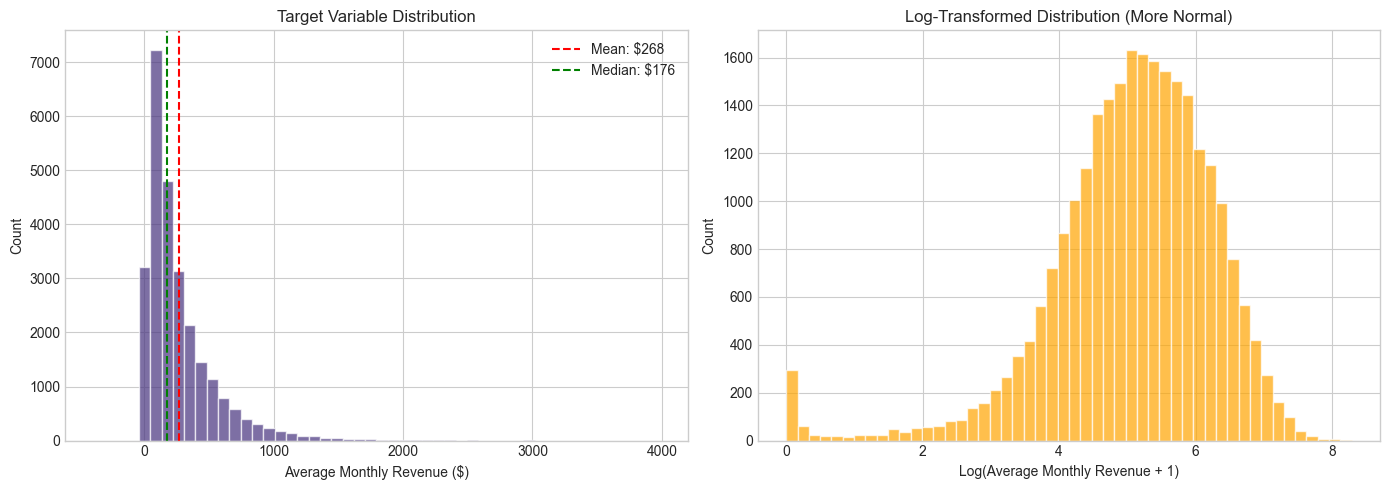

In [87]:
# Plot target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(target_data, bins=50, edgecolor='white', alpha=0.7)
axes[0].axvline(np.mean(target_data), color='red', linestyle='--', label=f'Mean: ${np.mean(target_data):,.0f}')
axes[0].axvline(np.median(target_data), color='green', linestyle='--', label=f'Median: ${np.median(target_data):,.0f}')
axes[0].set_xlabel('Average Monthly Revenue ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Variable Distribution')
axes[0].legend()

# Log-transformed histogram
log_target = np.log1p(target_data)
axes[1].hist(log_target, bins=50, edgecolor='white', alpha=0.7, color='orange')
axes[1].set_xlabel('Log(Average Monthly Revenue + 1)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-Transformed Distribution (More Normal)')

plt.tight_layout()
plt.show()

In [88]:
# Feature correlations with target
NUMERIC_FEATURES = [
    'log_total_revenue', 'log_nearest_site_distance_mi', 'log_min_distance_to_interstate_mi',
    'log_min_distance_to_kroger_mi', 'log_min_distance_to_mcdonalds_mi',
    'avg_household_income', 'median_age', 'pct_female', 'active_months'
]

print("Feature Correlations with Target (avg_monthly_revenue):")
print("=" * 60)

correlations = {}
for col in NUMERIC_FEATURES:
    if col in df_active.columns:
        corr = df_active.select(pl.corr(col, TARGET)).item()
        if corr is not None and not np.isnan(corr):
            correlations[col] = corr

# Sort by absolute correlation
sorted_corrs = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
for feature, corr in sorted_corrs:
    bar = '█' * int(abs(corr) * 20)
    sign = '+' if corr > 0 else '-'
    print(f"{feature:40} {sign}{abs(corr):.3f} {bar}")

Feature Correlations with Target (avg_monthly_revenue):
active_months                            +0.341 ██████
log_min_distance_to_mcdonalds_mi         -0.238 ████
log_min_distance_to_interstate_mi        -0.199 ███
avg_household_income                     +0.152 ███
log_nearest_site_distance_mi             -0.133 ██
log_min_distance_to_kroger_mi            -0.112 ██
median_age                               -0.089 █
pct_female                               +0.045 


## 8. Data Quality Checks

In [89]:
# Check for missing values in key columns
print("Missing Values Analysis (Active Sites):")
print("=" * 60)

key_cols = ['avg_monthly_revenue', 'log_total_revenue', 'avg_household_income', 
            'median_age', 'nearest_site_distance_mi', 'min_distance_to_interstate_mi',
            'min_distance_to_kroger_mi', 'min_distance_to_mcdonalds_mi']

for col in key_cols:
    if col in df_active.columns:
        null_count = df_active[col].null_count()
        pct = null_count / len(df_active) * 100
        print(f"{col:40} {null_count:6,} nulls ({pct:.1f}%)")

Missing Values Analysis (Active Sites):
avg_monthly_revenue                           0 nulls (0.0%)
log_total_revenue                             0 nulls (0.0%)
avg_household_income                         34 nulls (0.1%)
median_age                                   31 nulls (0.1%)
nearest_site_distance_mi                      0 nulls (0.0%)
min_distance_to_interstate_mi                 0 nulls (0.0%)
min_distance_to_kroger_mi                     0 nulls (0.0%)
min_distance_to_mcdonalds_mi                  0 nulls (0.0%)


## 9. Classification Target (Lookalike Model)

For binary classification, we identify "top performers" based on revenue percentile.

In [90]:
# Binary classification target: top 10% performers
threshold = np.percentile(target_data, 90)
is_top_performer = target_data >= threshold

print(f"Classification Target (Lookalike Model):")
print("=" * 40)
print(f"Threshold (90th percentile): ${threshold:,.2f}")
print(f"Positive class (top 10%): {is_top_performer.sum():,} sites ({is_top_performer.mean()*100:.1f}%)")
print(f"Negative class (bottom 90%): {(~is_top_performer).sum():,} sites ({(~is_top_performer).mean()*100:.1f}%)")
print(f"\nClass imbalance ratio: 1:{(~is_top_performer).sum() // is_top_performer.sum()}")

Classification Target (Lookalike Model):
Threshold (90th percentile): $613.30
Positive class (top 10%): 2,611 sites (10.0%)
Negative class (bottom 90%): 23,490 sites (90.0%)

Class imbalance ratio: 1:8


In [91]:
# Save processed data for next notebooks
OUTPUT_DIR = Path('./outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# Save the joined dataset
output_file = OUTPUT_DIR / 'processed_data.parquet'
df_active.write_parquet(output_file)
print(f"✓ Saved processed data to: {output_file}")
print(f"  Shape: {df_active.shape[0]:,} rows x {df_active.shape[1]} columns")

# Save data summary
data_summary = {
    'n_samples': len(df_active),
    'n_features': len(df_active.columns),
    'target': TARGET,
    'target_mean': float(np.mean(target_data)),
    'target_median': float(np.median(target_data)),
    'target_std': float(np.std(target_data)),
    'classification_threshold': float(threshold),
    'top_performer_count': int(is_top_performer.sum()),
    'source_files': {
        'site_scores': str(SITE_SCORES_FILE),
        'nearest_site': str(NEAREST_SITE_FILE),
        'interstate': str(INTERSTATE_FILE),
        'kroger': str(KROGER_FILE),
        'mcdonalds': str(MCDONALDS_FILE),
    }
}

import json
with open(OUTPUT_DIR / 'data_summary.json', 'w') as f:
    json.dump(data_summary, f, indent=2)
print(f"✓ Saved data summary to: {OUTPUT_DIR / 'data_summary.json'}")

✓ Saved processed data to: outputs/processed_data.parquet
  Shape: 26,101 rows x 44 columns
✓ Saved data summary to: outputs/data_summary.json


---

## Summary

This notebook has:
1. ✅ Loaded raw CSV data files (site scores, distances, metadata)
2. ✅ Explored data structure and ID relationships
3. ✅ Aggregated monthly data to site-level (one row per site)
4. ✅ Joined geospatial distance features
5. ✅ Analyzed target variable distribution
6. ✅ Performed data quality checks
7. ✅ Saved processed data for subsequent notebooks

**Key Findings:**
- Main data: ~500K monthly records → ~27K unique sites
- Target (avg_monthly_revenue): Right-skewed, log-transform recommended
- Distance features: 100% coverage for nearest site/interstate, ~100% for Kroger/McDonald's
- Class imbalance for lookalike model: ~9:1 ratio

**Data Pipeline:**
```
site_scores_revenue_and_diagnostics.csv (monthly)
    ↓ aggregate by id_gbase
One row per site
    ↓ join on gtvid
+ nearest_site_distances.csv
+ site_interstate_distances.csv  
+ site_kroger_distances.csv
+ site_mcdonalds_distances.csv
    ↓ filter to Active status
Training dataset (~26K sites)
```

**Next:** Proceed to `02_data_preprocessing.ipynb` for feature engineering and data preparation.